Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Часть 1: теория (5 pt)

### Данные

В реальной практике **80% времени уходит на анализ и подготовку данных**, а не на построение моделей или визуализацию. Грязные данные ведут к ошибочным выводам:

| Проблема | Последствие для анализа |
|----------|------------------------|
| **Пропуски** | Смещение средних значений, потеря наблюдений |
| **Дубликаты** | Завышенные частоты, искажённая статистика |
| **Аномалии** | Искажение корреляций, неработающие модели МО |
| **Несогласованный текст** | Невозможность группировки по категориям |

В этой части поработаем именно с этими четырьмя пунктами. Однако во второй части вы можете использовать любые известные вам методы.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Вот так можно смотреть версию (некоторые методы зависят от версии)
print(f"Pandas version: {pd.__version__}")

Мы начнём с [датасета](https://www.kaggle.com/datasets/zynicide/wine-reviews?spm=a2ty_o01.29997173.0.0.17c95171dBJybJ) — **Wine Reviews**. Этот датасет как раз подойдет нам для обсуждения методов.
> В описании датасета можно прочитать описание столбцов и их значение.

In [2]:
wine = pd.read_csv('winemag-data-130k-v2.csv')

print(wine.shape)
print(wine.columns.tolist())

(129971, 14)
['Unnamed: 0', 'country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery']


In [3]:
wine.head(3)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


Видно, что датасет считался некорректно и у нас появился столбец `Unnamed: 0`. Это произошло потому что pandas автоматически присваивает индексы, но в нашем датасете первый столбец уже был индексами. Это можно исправить с помощью чтения с параметром
```python
wine = pd.read_csv('winemag-data-130k-v2.csv', index_col=0)
```

Но мы пойдем другим способом и просто **удалим** этот столбец с помощью метода [.drop()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)

In [4]:
wine = wine.drop(columns=['Unnamed: 0'])

Также для того, чтобы нам было проще работать в этом задании удалим еще некоторые столбцы. То есть **оставим** только те, которые нам интересны.

In [5]:
wine = wine[['country', 'description', 'winery', 'designation', 'points', 'price', 'province', 'title', 'variety']]

In [6]:
wine.head()

,country,description,winery,designation,points,price,province,title,variety
0,Italy,"Aromas include tropical fruit, broom, brimston...",Nicosia,Vulkà Bianco,87,NaN,Sicily & Sardinia,Nicosia 2013 Vulkà Bianco (Etna),White Blend
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Quinta dos Avidagos,Avidagos,87,15.0,Douro,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red
2,US,"Tart and snappy, the flavors of lime flesh and...",Rainstorm,NaN,87,14.0,Oregon,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris
3,US,"Pineapple rind, lemon pith and orange blossom ...",St. Julian,Reserve Late Harvest,87,13.0,Michigan,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling
4,US,"Much like the regular bottling from 2012, this...",Sweet Cheeks,Vintner's Reserve Wild Child Block,87,65.0,Oregon,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir


### Диагностика проблем (1 pt)

Перед любыми действиями нужно **понять, какие проблемы есть в данных**. Базовый чек-лист:

| Проблема | Метод диагностики | Что ищем |
|----------|-------------------|----------|
| **Пропуски** | `.isna().sum()` | Количество `NaN` по столбцам |
| **Дубликаты** | `.duplicated().sum()` | Полные или частичные повторы строк |
| **Аномалии** | `.describe()` + визуализация | Значения за пределами ожидаемого диапазона |
| **Несогласованный текст** | `.value_counts()` | Опечатки, разный регистр, лишние пробелы |

Сууждения об аномалиях можно делать на основе жизненной (бизнес) логики (не может кот весить тонну) и/или странных сочетаний `min`, `mean`, `max` и других статистик.  
В репорте `value_counts` видно, сколько раз повторяется значение. Поэтому если строковое значение повторяется только один раз (хотя при это, например, категория), то стоит задуматься о том, что нужно данные как-то преобразовать. 

> Про некоторые методы вы уже знаете, а про остальные можно посмотреть в документации: [pandas.DataFrame.isna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html), [pandas.DataFrame.duplicated](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html).

***

Предположим, что мы совсем не разбираемся в вине (надеюсь, что вам и предполагать не надо) и хотим что-то про него понять. Например какое и за сколько лучше всего. *Таисия Вячеславовна, в вине может и нет, а вот в пакетированной бурде по типу Изабеллы я спец. Жалко, её тут нет(((*

In [7]:
# ЗАДАНИЕ:
#          1. Посчитайте количество пропусков (NaN) по каждому столбцу
#          2. Найдите количество полных дубликатов строк
#          3. Выведите базовую статистику для числовых столбцов
#          4. Проанализируйте распределение цены — есть ли подозрительные значения?
#          5. Напишите небольшой вывод о водможных проблемах с данными

for col in ['country', 'description', 'winery', 'designation', 'points', 'price', 'province', 'title', 'variety']:
    print(f'NaN в {col}: {wine[col].isna().sum()}')
print(f'Дубликатов строк: {wine.duplicated().sum()}')
wine.describe()

NaN в country: 63
NaN в description: 0
NaN в winery: 0
NaN в designation: 37465
NaN в points: 0
NaN в price: 8996
NaN в province: 63
NaN в title: 0
NaN в variety: 1
Дубликатов строк: 9983


,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


# Краткие тезисные выводы:
- показало довольно много дубликатов строк (примерно 8% данных, надо почистить) 
- незначительное количество NaN в variety, province, country
- неприятное количество NaN в price, значимом столбце
- значительно (больше 1/4 данных) NaN в designation
- В цене значения [4, 3300] - сильно большой разброс, в то время как среднее - 35. Думаю, можно считать значения > 100 аномальными (75% данных - до 42)
- По рейтингу всё норм - [80, 100], ещё и пропусков нет, разве что меня лично смутило значение стандартного отклонения, как будто 3 - слишком мало...

<details>
  <summary>Когда будете готовы, кликните сюда, чтобы посмотреть краткую сводку</summary>
    <ol>
      <li> Безусловно для нас важнее всего цена, а в этом столбце много пропусков, нужно с ними что-то делать. Также в цене есть явно аномальные (сильно маленькие или сильно большие значения), нужно понять, как с ними работать.</li>
      <li>В целом в разных столбцах есть пропуски, но вот в столбце designation их слишком много (37к).</li>
      <li>Рейтинги не содержат явных аномалий — все значения в ожидаемом диапазоне (80-100 баллов).</li>
    </ol> 
</details>

### Обработка дубликатов (0,5 pt)

In [8]:
wine.duplicated().sum()

9983

Дубликаты — это полные или частичные повторы строк, которые искажают статистику. В датасете вин есть 9 983 дубликата. Такие повторы будут портить нам статистику, поэтому их лучше удалить.
Поможет в этом [.drop_duplicates()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html)

In [9]:
# ЗАДАНИЕ: Удалите дубликаты, оставив только первую запись
wine = wine.drop_duplicates()

In [10]:
wine.duplicated().sum()

0

### Обработка пропусков (1 pt)

Выбор стратегии работы с пропусками зависит от **природы пропуска**. Например для цены нам критично заполнение пропусков, а вот в столбце `designation` (виноградник на территории винодельни, откуда собирают виноград, из которого делают вино) пропуски для нас некритичны и мы можем заменить их на нейтральное значение нужного типа (`str` "Undefined").

Прочитать про то, как можно работать с пропусками можно много где, например, [тут](https://www.geeksforgeeks.org/data-analysis/working-with-missing-data-in-pandas/) и [здесь](https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/).

Главное при заполнении пропусков следовать логике и делать так, чтобы стратегия заполнения не ломала данные. Например можно заполнять пропуски **средним (или наиболее частым) значением по какому-то условию**. Если пропусков мало или они не значимы, то можно удалять такие строки.

_Иногда важно смотреть внимательно: не всегда пропуски видны, иногда вместо `NaN` значения содержат нули или неопределенные слова. Такие случаи тоже можно считать пропусками, но в этом датасете такого нет._

***

Сейчас мы не будем сильно заморачиваться с этим и просто попробуем разные методы:
* в столбце `country` **заменим пропуски на наиболее часто встречаемую** страну (пропусков не так много, чтобы они повлияли, да и если страна неизвестна, то с оцень большой вероятностью это Италия или Франция)
* В столбце `designation` заменим пропуски на метку "Undefined". Это нормально, что для массовых вин никого не заботит виноградник. Но для того, чтобы мы корректно могли работать со строками заменим наны на строку.
* В столбце `price` заменим пропуски **медианой** по стране. Медианой, а не средним для того, чтобы не влияли выбросы и не появлялись дробные значения.
* В столбце `province` заполним пропуски **модой** по стране (наиболее частым).
* Строку с пропуском в столбце `variety` просто **удалим**)

Для начала сделаем **копию датасета** для того, чтобы не потерять изначальные данные!

Вам помогут: [.fillna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html), [.transform()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html), [.dropna()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html).

In [11]:
wine.isna().sum()

country           59
description        0
winery             0
designation    34545
points             0
price           8395
province          59
title              0
variety            1
dtype: int64

In [12]:
wine_clean = wine.copy()

In [13]:
# ЗАДАНИЕ: обработайте пропуски согласно пунктам выше

# тут мы заменяем пропуски на наиболее часто встречаемую страну
most_common_country = wine['country'].mode()[0]
wine_clean['country'] = wine_clean['country'].fillna(most_common_country)  

wine_clean['designation'] = wine_clean['designation'].fillna('Undefined')

# тут, как я понял, нужно для каждой страны вычислить свою медиану и заполнить значением именно для неё
#Оказывается, в группе все значения могут быть NaN. Тогда заполним эту ячейку просто медианой
country_median_price = wine_clean['price'].median()
wine_clean['price'] = wine_clean.groupby('country')['price'].transform(lambda x: x.fillna(x.median()) if not x.median().isnull() else country_median_price)

# тут аналогично - вычисляем для каждой страны отдельно
wine_clean['province'] = wine_clean.groupby('country')['province'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

wine_clean = wine_clean.dropna(subset=['variety'])

In [14]:
# Должно быть по нулям
wine_clean.isna().sum()

country        0
description    0
winery         0
designation    0
points         0
price          0
province       0
title          0
variety        0
dtype: int64

### Обработка аномалий (0,5 pt)

Аномалии (выбросы) — это значения, которые **значительно отклоняются** от остальных наблюдений. Они могут быть:
- **Ошибка измерения/ввода** (цена вина отрицательна) -> удалить
- **Редкое, но валидное наблюдение** (винтажное вино за много денег) -> сохранить или обработать отдельно
- **Систематическое искажение** (группировка значений на границах) -> исследовать источник

_Можно выделить три подхода для обнаружения аномалий или подбора порогов_

| Подход | Как работает | Плюсы | Минусы | Когда применять |
|--------|--------------|-------|--------|-----------------|
| **Бизнес-логика** | Определение границ на основе экспертных знаний предметной области | Интерпретируемо, учитывает контекст, не требует сложных вычислений | Требует экспертизы, субъективно | Когда есть чёткие физические/экономические ограничения (цена ≥ 0, возраст 0–120 лет) |
| **Статистика (IQR)** | Границы: `Q1 - 1.5×IQR` и `Q3 + 1.5×IQR`, где `IQR = Q3 - Q1` | Автоматизируемо, не зависит от распределения | Может удалить валидные экстремумы, чувствителен к выбору коэффициента (1.5 vs 3.0) | Когда нет экспертных знаний, но нужно быстро найти «подозрительные» значения |
| **Статистика (Z-score)** | Границы: $|z| > 3$, где $z = (x - \mu) / \sigma$ | Хорошо работает для нормальных распределений | Требует нормальности данных, чувствителен к выбросам при расчёте $\mu$ и $\sigma$ | Для признаков с приблизительно нормальным распределением |

Вот тут есть [гайд](https://sky.pro/wiki/media/kakie-sushhestvuyut-metody-opredeleniya-vybrosov-v-dannyh/) про то, как определять выбросы.

> Также для этого поможет документация: [.quantile()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html), [scipy.stats.zscore](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html).

**Что же делать с аномалиями?**

| Стратегия | Когда применять | Пример |
|----------|-------------------|----------|
| **Удаление** | Аномалия — явная ошибка (цена $\leqslant$ $0) | `df = df[df['price'] > 0]` |
| **Ограничение (capping)** | Аномалия — экстремум, но не ошибка | `df['price'] = df['price'].clip(upper=500)` |
| **Сегментация** | Аномалии образуют отдельный сегмент | `df['segment'] = pd.cut(df['price'], bins=[0, 50, 100, float('inf')])` |
| **Сохранение с пометкой** | Нужно анализировать аномалии отдельно | `df['is_outlier'] = df['price'] > 500` |

Кажется, что в нашем случае лучшим решением будет **поделить** вина **на категории**: дешевые, нормальные, очень дорогие. Для того, чтобы лучше понять данные посмотрим на **диаграмму** цен ([DataFrame.plot.hist](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.hist.html))

<Axes: ylabel='Frequency'>

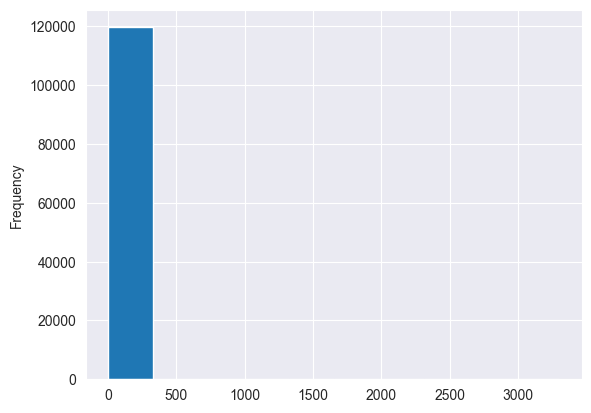

In [15]:
wine_clean.price.plot.hist()

_Какие пороги для ценовых категорий стоит поставить?_

Получился какой-то неинформативный график, всё, что я отсюда могу понять - все (почти) цены меньше 450.

In [16]:
# ЗАДАНИЕ: 1. Создать новый столбец wine_clean['price_category']
#          2. Согласно выявленным порогам определить ценовую категорию каждого вина

# оказывается, можно использовать функции, и это оч круто!
# распраделение взял из головы, подбирал, получилось +- ровно
# def categorize_price(price):
#     if price < 20:
#         return 'cheap'
#     elif price < 35:
#         return 'average'
#     else:
#         return 'expensive'

# решил, что подход выше - дурацкий, лучше по квантилям

cheap_threshold = wine_clean['price'].quantile(0.25)
expensive_threshold = wine_clean['price'].quantile(0.75)

def categorize_price(price):
    if price < cheap_threshold:
        return 'cheap'
    elif price < expensive_threshold:
        return 'average'
    else:
        return 'expensive'

wine_clean['price_category'] = wine_clean['price'].apply(categorize_price)

In [17]:
wine_clean['price_category'].value_counts()

price_category
average      60683
expensive    32720
cheap        26584
Name: count, dtype: int64

### Обработка текста (0,5 pt)

Текстовые данные в реальных датасетах часто содержат **несогласованные обозначения**, которые мешают корректной группировке и анализу. Например могут быть следующие проблемы:

| Столбец | Проблема | Примеры из данных |
|---------|----------|-------------------|
| `country` | Разные форматы для одной страны | `'US'`, `'USA'`, `'U.S.A.'`, `'United States'` |
| `province` | Разный регистр и лишние пробелы | `' california '`, `'California'`, `'CALIFORNIA'` |
| `variety` | Опечатки и синонимы | `'Pinot Noir'` vs `'PinotNoir'` |

Нам повезло, в нашем датасете такого нет, однако, встретиться такое может часто.

**Как приводить текстовые/категориальные данные в общий вид?**

| Метод | Назначение | Пример |
|-------|------------|--------|
| `.str.strip()` | Удаляет пробелы по краям | `' California '` → `'California'` |
| `.str.lower()` / `.str.title()` | Приводит к единому регистру | `'california'` → `'California'` |
| `.replace()` | Заменяет значения по словарю | `{'US': 'United States'}` |
| `.str.contains()` | Поиск подстроки (регистронезависимый) | `contains('berry', case=False)` |

Как всегда подробнее в документации: [.str.strip()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html),
[.str.lower()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.lower.html),
[.replace()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html),
[.str.contains()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html).

In [18]:
# Проверьте, что в нашем датасете нет таких проблем
# Решил проверить столбец 'country'
print(wine_clean['country'].value_counts().head(20))  
print(wine_clean['country'].unique()[:50])          

country
US              50516
France          20353
Italy           17940
Spain            6116
Portugal         5256
Chile            4183
Argentina        3544
Austria          3034
Australia        2197
Germany          1992
South Africa     1301
New Zealand      1278
Israel            466
Greece            432
Canada            226
Bulgaria          132
Hungary           129
Romania           102
Uruguay            98
Turkey             81
Name: count, dtype: int64
<StringArray>
[                 'Italy',               'Portugal',                     'US',
                  'Spain',                 'France',                'Germany',
              'Argentina',                  'Chile',              'Australia',
                'Austria',           'South Africa',            'New Zealand',
                 'Israel',                'Hungary',                 'Greece',
                'Romania',                 'Mexico',                 'Canada',
                 'Turkey',         'Cz

Что касается текстовых данных, то у нас есть очень информативный столбец `description`, из которого можно вытащить много информации. Для того, чтобы это было сделать легче, приведем все буквы к строчному виду и удалим знаки препинания.

In [19]:
# ЗАДАНИЕ: приведите описания к нижнему регистру и удалите знаки препинания
wine_clean['description'] = wine_clean['description'].str.lower().replace('[,:;.]', '', regex=True)

In [20]:
wine_clean.description[42]

'this is a festive wine with soft ripe fruit and acidity plus a red berry flavor'

### Вывод (1,5 pt)

Теперь по подготовленным данным ответьте на следующие вопросы (**напишите код и небольшие выводы**):
- Какая страна производит самые дорогие вина (по средней цене)? Какая — самые дешёвые? Какие страны производят очень дорогие вина?
- Есть ли связь между ценой и рейтингом? Вина какой ценовой категории получают самый высокий средний рейтинг?
- Какие 3 сорта винограда (variety) самые лучшие (по цене, по рейтингу)?
- Сравните средний рейтинг разных ценовых сегментов. Насколько отличается качество между бюджетным и премиум-сегментом?
- В каких ценовых сегментах встречаются фруктовые вина (посмотрите вхождения ключевых слов в описания)? 

 ### Самые дорогие вина / Самые дешёвые вина / Очень дорогие вина

In [21]:
# Средняя цена по странам
mean_price_by_country = wine_clean.groupby('country')['price'].mean()

# Самая дорогая страна
most_expensive = mean_price_by_country.idxmax()
cheapest = mean_price_by_country.idxmin()

print(f"Самая дорогая страна: {most_expensive} ({mean_price_by_country.max():.3f})")
print(f"Самая дешёвая страна: {cheapest} ({mean_price_by_country.min():.3f})")

# Страны, производящие очень дорогие вина (выше квантиля 0,95)
high_price_threshold = wine_clean['price'].quantile(0.95)
very_expensive = wine_clean[wine_clean['price'] > high_price_threshold]
top_countries_very_expensive = very_expensive['country'].value_counts().head(5)
print(f"\nСтраны, чаще всего производящие очень дорогие вина (стоимостью > {high_price_threshold}):")
print(top_countries_very_expensive)
print("\n")
# Интересно, сколько вин производит Швейцария, потому что в список стран она не попала
print(f'Швейцарии в датасете всего {wine_clean[wine_clean.country == "Switzerland"].shape[0]} штук')
# Тогда интересно, сколько вин производит US
print(f'US в датасете всего {wine_clean[wine_clean.country == "US"].shape[0]} штук')
# Поняяятненько

Самая дорогая страна: Switzerland (72.833)
Самая дешёвая страна: Ukraine (9.214)

Страны, чаще всего производящие очень дорогие вина (стоимостью > 82.0):
country
US           2189
France       1422
Italy        1214
Spain         293
Australia     170
Name: count, dtype: int64


Швейцарии в датасете всего 6 штук
US в датасете всего 50516 штук


### Вывод
Несмотря на то, что в среднем самая дорогая цена вин у Швейцарии, судя по всему она их производит мало, поэтому не попала в список стран, которые больше всего дорогих вин производят

### Связь между ценой и рейтингом, ценовая категория вин с самым высоким рейтингом

In [22]:
# Корреляция между ценой и рейтингом (как же удобно проверяется корреляция в Pandas!!!!
pirson_correlation = wine_clean['price'].corr(wine_clean['points'])
spearman_correlation = wine_clean['price'].corr(wine_clean['points'], method='spearman')
print(f"Корреляция между ценой и рейтингом: Пирсона: {pirson_correlation:.3f}, Спирмана: {spearman_correlation:.3f}")

Корреляция между ценой и рейтингом: Пирсона: 0.399, Спирмана: 0.586


### Вывод
Неудивительно, что дорогие вина получили самый высокий рейтинг, корреляция между ценой и рейтингом достаточно большая

### Лучшие сорта по цене / рейтингу

In [23]:
top_varieties_price = wine_clean.groupby('variety')['price'].mean().sort_values(ascending=False).head(3)
print("Топ-3 сорта по средней цене:")
print(top_varieties_price)

top_varieties_rating = wine_clean.groupby('variety')['points'].mean().sort_values(ascending=False).head(3)
print("\nТоп-3 сорта по среднему рейтингу:")
print(top_varieties_rating)

Топ-3 сорта по средней цене:
variety
Ramisco      495.0
Terrantez    236.0
Francisa     160.0
Name: price, dtype: float64

Топ-3 сорта по среднему рейтингу:
variety
Terrantez          95.0
Gelber Traminer    95.0
Tinta del Pais     95.0
Name: points, dtype: float64


### Вывод
Не знаю, что тут комментировать... Ну, разрыв большой между топ-3 сортами по средней цене, а вот по рейтингу он отсутствует. 
Интересно, что топ-1 по цене не попал в топ-3 по рейтингу. На основе этих данных нельзя сделать вывод, какое вино лучшее. Мне вот кажется, что лучшее, это то, у которого minmax цена рейтинг. Давайте попробуем найти такое вино.

In [24]:
# Допустим, я хочу, чтобы оценка вина по рейтингу была больше 90, но цена была наименьшей
wine_clean_best = wine_clean[(wine_clean['points'] > 90)]
wine_clean_best = wine_clean_best[wine_clean_best['price'] == wine_clean_best['price'].min()]
print(f"Топ-1 по цене, но с оценкой > 90: {wine_clean_best['variety'].values[0]}, цена: {wine_clean_best['price'].values[0]}, рейтинг: {wine_clean_best['points'].values[0]}")

# Допустим, я хочу, чтобы цена была меньше 100, но оценка была наибольшей
wine_clean_best = wine_clean[(wine_clean['price'] < 100)]
wine_clean_best = wine_clean_best[wine_clean_best['points'] == wine_clean_best['points'].max()]
print(f"Топ-1 по оценке, но с ценою < 100: {wine_clean_best['variety'].values[0]}, цена: {wine_clean_best['price'].values[0]}, рейтинг: {wine_clean_best['points'].values[0]}")

Топ-1 по цене, но с оценкой > 90: Portuguese Red, цена: 7.0, рейтинг: 91
Топ-1 по оценке, но с ценою < 100: Syrah, цена: 80.0, рейтинг: 100


 #### **Да ну его этот Terrantez за 236, если я могу взять Portuguese Red в 34 раза дешевле, а в рейтинге потерять всего 4 балла, или и вовсе Syrah в 3 раза дешевле, но с более крутым рейтингом!**
 
*Да, я понимаю, что выше было взято по среднему рейтингу, но вы посмотрите, какая находка!!!*

### Средний рейтинг разных ценовых сегментов

In [25]:
rating_by_category = wine_clean.groupby('price_category')['points'].mean()
print(rating_by_category)
diff = rating_by_category.max() - rating_by_category.min()
print(f"\nРазница между премиум и бюджетным сегментом: {diff:.2f} балла")

price_category
average      88.259826
cheap        85.978521
expensive    90.782243
Name: points, dtype: float64

Разница между премиум и бюджетным сегментом: 4.80 балла


### Вывод 
Весьма прозаичен: если вы не сомелье, смысла брать премиум нет, вы в среднем потеряете лишь 4 балла рейтинга, если возьмёте вино из бюджетного сегмента.

### В каких ценовых сегментах чаще встречаются фруктовые вина

In [26]:
fruit_wines = wine_clean[wine_clean['description'].str.contains('fruit')]

fruit_wines_count = fruit_wines.shape[0]

for category in fruit_wines['price_category'].unique():
    print(f'В категории {category} встречается {fruit_wines[fruit_wines["price_category"] == category].shape[0] *100 / fruit_wines_count:.2f}% фруктовых вин')


В категории average встречается 51.85% фруктовых вин
В категории cheap встречается 22.70% фруктовых вин
В категории expensive встречается 25.45% фруктовых вин


### Вывод
Фруктики можно найти везде, их везде навалом (average сегмент просто в 2 раза больше остальных). Может, лучше посмотреть, в каких странах больше фруктовых вин в соотношении с остальными?

In [27]:
wine_clean['has_fruit'] = wine_clean['description'].str.contains(r'fruit')

# Группируем по странам и сбрасываем индекс, чтобы country стала столбцом
country_stats = wine_clean.groupby('country').agg(total_wines=('has_fruit', 'size'),fruit_wines=('has_fruit', 'sum')).reset_index()
country_stats['fruit_ratio'] = country_stats['fruit_wines'] / country_stats['total_wines']
country_stats = country_stats[country_stats['total_wines'] >= 10]

# Сортируем по убыванию доли и берём топ-10
top_fruit_countries = country_stats.sort_values('fruit_ratio', ascending=False).head(10)

print("Топ-10 стран по доле вин с фруктовыми нотами в описании:\n")
print(top_fruit_countries[['country', 'total_wines', 'fruit_wines', 'fruit_ratio']].to_string(index=False))

Топ-10 стран по доле вин с фруктовыми нотами в описании:

       country  total_wines  fruit_wines  fruit_ratio
      Portugal         5256         4232     0.805175
        France        20353        15338     0.753599
        Cyprus           10            7     0.700000
          Peru           16           10     0.625000
   New Zealand         1278          755     0.590767
        Canada          226          133     0.588496
       Austria         3034         1751     0.577126
     Macedonia           11            6     0.545455
Czech Republic           11            6     0.545455
        Greece          432          233     0.539352


### Вывод:
Во, вот это круто! В Португалии 80% вин - фруктовые, во Франции - 75%

# Часть 2: практика (5 pt)

**В этой части вам нужно самостоятельно провести анализ датасета и сделать выводы.**
***
**ЗАДАНИЕ: подготовить данные и сделать три неочевидных/интересных вывода (основывающихся на данных)**
***
В качестве датасета возьмем данные [Netflix](https://www.kaggle.com/datasets/shivamb/netflix-shows/data). 

> Оцениваться будут следующие пункты:
> * Диагностика проблем (1 pt)
> * Подготовка и очистка данных, в том числе добавление новых столбцов, выделение категорий и тд. Важна аргуменитация и пояснения выбора методов.(2 pt)
> * Анализ данных и выводы (2 pt)

В качестве отправной точки можете использовать вопросы:
- Какие 3 страны производят больше всего контента для Netflix? Есть ли различия между фильмами и сериалами?
- В каком году было выпущено максимальное количество сериалов?
- Какой возрастной рейтинг самый распространённый для фильмов? Для сериалов? Есть ли страна, где доминируют контент со взрослым рейтингом?
- Какова медианная продолжительность фильмов (в минутах)? Сериалов (в сезонах)?
- Какой жанр доминирует в США? В Индии?
- Какой тип контента «старше»?

**Пожалуйста, оформляйте ваш код и выводы аккуратно, при необходимости добавляйте секции и форматируйте текст.**

In [28]:
#Переименовал movie на netflix, в конце концов, тут далеко не только фильмы
netflix = pd.read_csv('netflix_titles.csv')
#На всякий случай сохраню себе сырой
raw_netflix = netflix.copy()

netflix.shape

(8807, 12)

In [29]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Диагностика проблем
Ну, давайте пойдём по стандартному пайплайну: 
- Проверим наличие пропусков
- Уберём дубликаты
- Проверим аномалии
- Проверим на согласованный текст

Для начала, видим, что у нас есть поле show_id. Ну, сделаем так, как в примере - дропнем этот столбец. ***Заметим, что*** у нас снова есть поля, которые нам не интересны (по моему мнению): ['date_added', 'description']. Остальное пусть живёт.

In [30]:
netflix = netflix.drop(columns = ['show_id', 'date_added', 'description'])

In [31]:
for col in ['type', 'title', 'director', 'cast', 'country', 'release_year', 'rating', 'duration', 'listed_in']:
    print(f'NaN в {col}: {netflix[col].isna().sum()}')
print(f'Дубликатов строк: {netflix.duplicated().sum()}')
netflix = netflix.drop_duplicates()

NaN в type: 0
NaN в title: 0
NaN в director: 2634
NaN в cast: 825
NaN в country: 831
NaN в release_year: 0
NaN в rating: 4
NaN в duration: 3
NaN в listed_in: 0
Дубликатов строк: 0


### Устранение пропусков
- Думаю, director и cast заполнять чем-то кроме 'Unknown' бессмысленно. 
- country можно попробовать заполнить модой по жанру???
- в rating всего 4 пропуска - можно заполнить медианой
- с duration всё сложно, есть по минутам, есть по сезонам...

Давайте начнём с простого:

In [32]:
netflix['director'] = netflix['director'].fillna('Unknown')
netflix['cast'] = netflix['cast'].fillna('Unknown')

most_common_country = netflix['country'].mode()[0]
netflix['country'] = netflix['country'].fillna(most_common_country)

#Позже я заметил, что в некоторых фильмах длительность съехала в rating. предварительно поставим её на место
mask = netflix['rating'].str.contains(r'\d', na=False)
netflix.loc[mask, 'duration_value'] = netflix.loc[mask, 'rating'].str.extract(r'(\d+)').astype(int)
netflix.loc[mask, 'rating'] = np.nan

most_common_rating = netflix['rating'].mode()[0]
netflix['rating'] = netflix['rating'].fillna(most_common_rating)

netflix.head(15)

,type,title,director,cast,country,release_year,rating,duration,listed_in,duration_value
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,TV-MA,90 min,Documentaries,NaN
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",NaN
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",NaN
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,1 Season,"Docuseries, Reality TV",NaN
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",NaN
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",NaN
6,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021,PG,91 min,Children & Family Movies,NaN
7,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",NaN
8,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-MA,9 Seasons,"British TV Shows, Reality TV",NaN
9,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,TV-MA,104 min,"Comedies, Dramas",NaN


Думаю, логично будет разграничить сериалы и фильмы, разделив duration на 2 колонки:

`duration_value` - длительность, но в каких единицах?
В единицах `duration_unit` - сезоны / минуты

В соотвествии с типом (сериал или фильм) будем заполнять duration

In [33]:
# Хотел с помощью split, но не получилось, т.к. есть же наны.. Решил попробовать регуляркой, получилось
netflix[['duration_value', 'duration_unit']] = netflix['duration'].str.extract(r'(\d+)\s*(\w+)') 
netflix['duration_value'] = pd.to_numeric(netflix['duration_value'])

# Есть варианты 'Season' вместо 'Seasons', приведём к единому виду заранее 
netflix['duration_unit'] = netflix['duration_unit'].replace({'Season': 'Seasons'})

# Заполняем пропуски в value медианами по типу 
movie_median = netflix[netflix['type'] == 'Movie']['duration_value'].median()
tv_median = netflix[netflix['type'] == 'TV Show']['duration_value'].median()

netflix.loc[(netflix['type'] == 'Movie') & (netflix['duration_value'].isna()), 'duration_value'] = movie_median
netflix.loc[(netflix['type'] == 'TV Show') & (netflix['duration_value'].isna()), 'duration_value'] = tv_median

# Заполняем пропуски в duration_unit по типу
netflix.loc[netflix['type'] == 'Movie', 'duration_unit'] = netflix.loc[netflix['type'] == 'Movie', 'duration_unit'].fillna('min')
netflix.loc[netflix['type'] == 'TV Show', 'duration_unit'] = netflix.loc[netflix['type'] == 'TV Show', 'duration_unit'].fillna('Seasons')

netflix = netflix.drop(columns=['duration'])
netflix.head()

,type,title,director,cast,country,release_year,rating,listed_in,duration_value,duration_unit
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,TV-MA,Documentaries,90.0,min
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",2.0,Seasons
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",1.0,Seasons
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,"Docuseries, Reality TV",1.0,Seasons
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",2.0,Seasons


In [34]:
netflix.isna().sum()
netflix.duplicated().sum()

0

Отлично, пропусков нет, дубликатов тоже, дальше по плану - аномалии, согласованный текст

In [35]:
# Давайте посмотрим на аномалии, например, по длительности. Логичнее будет разделить на фильмы и сериалы
netflix_movies = netflix[netflix['type'] == 'Movie']
netflix_shows = netflix[netflix['type'] == 'TV Show']


netflix_movies['duration_value'].describe()

count    6131.000000
mean       99.576415
std        28.283691
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

В среднем полтора часа фильм, окей. Существует фильм длиной в минуту??? Фильм длиной в 5 часов?

Давайте посмотрим, сколько таких фильмов

In [36]:
too_short = netflix_movies[netflix_movies['duration_value'] < 10]
too_long = netflix_movies[netflix_movies['duration_value'] > 240]

netflix_movies = netflix_movies[netflix_movies['duration_value'].between(10, 240)]

too_short.shape, too_long.shape



((4, 10), (3, 10))

Всего 4 фильма длиной менее 10 минут, 3 фильмов длиной более 240 минут. Мне кажется, такие аномалии можно и вырезать, не учитывать их, либо проанализировать их после отдельно. Поскольку я не спец по фильмам и сериалам, думаю, можно просто порезать по квантилям. Но сначала, всё же, взглянем на сериалы:

In [37]:
netflix_shows['duration_value'].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64

### Принимаем волевое (в силу своей некомпетентности) решение: режем по квантилям. 
Фильмы - и слева, и справа
Сериалы - только справа

In [38]:
# Для сериалов: оставляем только те, у которых duration_value <= 95-го перцентиля
shows_95 = netflix_shows['duration_value'].quantile(0.95)
netflix_shows_trimmed = netflix_shows[netflix_shows['duration_value'] <= shows_95]

# Для фильмов: оставляем значения между 5-м и 95-м перцентилями
movies_lower = netflix_movies['duration_value'].quantile(0.05)
movies_upper = netflix_movies['duration_value'].quantile(0.95)
netflix_movies_trimmed = netflix_movies[
    (netflix_movies['duration_value'] >= movies_lower) & 
    (netflix_movies['duration_value'] <= movies_upper)
]

# Собираем наш чистенький датасетик
netflix = pd.concat([netflix_movies_trimmed, netflix_shows_trimmed])

# Посмотрим, сколько урезали
print(f"Фильмов до: {len(netflix_movies)}, после: {len(netflix_movies_trimmed)}")
print(f"Сериалов до: {len(netflix_shows)}, после: {len(netflix_shows_trimmed)}")

Фильмов до: 6124, после: 5525
Сериалов до: 2676, после: 2577


Возможно, потеря в 600 фильмов - слишком большая, всё же... Тем не менее, намерен оставить так. Дальше - согласованный текст. Посмотрим, что по странам:

In [39]:
# Решил разделить список стран на два столбца - список и количество стран
netflix['countries_list'] = netflix['country'].str.split(r'\s*,\s*')
netflix['countries_amount'] = netflix['countries_list'].str.len()

netflix = netflix.drop(columns=['country'])
print(netflix['countries_amount'].value_counts())

countries_amount
1     6853
2      820
3      264
4      107
5       36
6       13
7        5
8        2
12       1
10       1
Name: count, dtype: int64


In [40]:
# Наверное, хочется аналогично сделать с director, cast и listed_in, чтобы удобно работать с числовыми характеристиками
netflix['directors_list'] = netflix['director'].str.split(r'\s*,\s*')
netflix['directors_amount'] = netflix['directors_list'].str.len()
netflix = netflix.drop(columns=['director'])

netflix['actors_list'] = netflix['cast'].str.split(r'\s*,\s*')
netflix['actors_amount'] = netflix['actors_list'].str.len()
netflix = netflix.drop(columns=['cast'])


netflix['genres_list'] = netflix['listed_in'].str.split(r'\s*,\s*')
netflix['genres_amount'] = netflix['genres_list'].str.len()
netflix = netflix.drop(columns=['listed_in'])

netflix.head()

,type,title,release_year,rating,duration_value,duration_unit,countries_list,countries_amount,directors_list,directors_amount,actors_list,actors_amount,genres_list,genres_amount
0,Movie,Dick Johnson Is Dead,2020,TV-MA,90.0,min,[United States],1,[Kirsten Johnson],1,[Unknown],1,[Documentaries],1
6,Movie,My Little Pony: A New Generation,2021,PG,91.0,min,[United States],1,"[Robert Cullen, José Luis Ucha]",2,"[Vanessa Hudgens, Kimiko Glenn, James Marsden,...",10,[Children & Family Movies],1
7,Movie,Sankofa,1993,TV-MA,125.0,min,"[United States, Ghana, Burkina Faso, United Ki...",6,[Haile Gerima],1,"[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra ...",8,"[Dramas, Independent Movies, International Mov...",3
9,Movie,The Starling,2021,TV-MA,104.0,min,[United States],1,[Theodore Melfi],1,"[Melissa McCarthy, Chris O'Dowd, Kevin Kline, ...",11,"[Comedies, Dramas]",2
12,Movie,Je Suis Karl,2021,TV-MA,127.0,min,"[Germany, Czech Republic]",2,[Christian Schwochow],1,"[Luna Wedler, Jannis Niewöhner, Milan Peschel,...",11,"[Dramas, International Movies]",2


Думаю, теперь мы готовы отвечать на вопросы. Я бы считал данные достаточно предобработанными

### Вопрос 1: Какие 3 страны производят больше всего контента для Netflix? Есть ли различия между фильмами и сериалами?

In [41]:
all_countries = netflix['countries_list'].explode().value_counts()
main_countries = all_countries.head(5)


netflix_movies = netflix[netflix['type'] == 'Movie']
movies_countries = netflix_movies['countries_list'].explode().value_counts()
movies_countries = movies_countries.head(5)


netflix_shows = netflix[netflix['type'] == 'TV Show']
shows_countries = netflix_shows['countries_list'].explode().value_counts()
shows_countries = shows_countries.head(5)

print(f"Всего стран: {main_countries}\n\nФильмы: {movies_countries}\n\nСериалы: {shows_countries}")

Всего стран: countries_list
United States     4147
India              843
United Kingdom     755
Canada             405
France             385
Name: count, dtype: int64

Фильмы: countries_list
United States     2895
India              759
United Kingdom     491
France             296
Canada             291
Name: count, dtype: int64

Сериалы: countries_list
United States     1252
United Kingdom     264
Japan              195
South Korea        169
Canada             114
Name: count, dtype: int64


### Выводы по вопросу 1:
- Наибольший вклад везде внесла США, с гиганстким отрывом (вклад в 50% медиа датасета)
- Индия производит в основном фильмы, в сериалы большого вклада нет (даже в топ-5 по сериалам не входит, специально расширил head, чтобы это проверить)

### Вопрос 2: В каком году было выпущено максимальное количество сериалов?

In [42]:
shows_year = netflix_shows['release_year'].value_counts()
max_year = shows_year.idxmax()
print(f"Максимальное количество сериалов было выпущено в {max_year} году")

Максимальное количество сериалов было выпущено в 2020 году


Ну окей... Вывода тут не сделаешь

### Вопрос 3: Какой возрастной рейтинг самый распространённый для фильмов? Для сериалов? Есть ли страна, где доминирует контент со взрослым рейтингом?

Как я понял, из представленных рейтингов являются взрослыми R и TV-MA. На них и будем ориентироваться
Вообще, нейронка подсказывает, что NR и UR - тоже для взрослых, но это "not rated" и "unrated", так что их учитывать не будем

In [43]:
netflix_movies['rating'].value_counts()
netflix_shows['rating'].value_counts()

print(f"Самый распространённый рейтинг:\nДля фильмов: {netflix_movies['rating'].value_counts().idxmax()}\nДля сериалов: {netflix_shows['rating'].value_counts().idxmax()}")

# Найдём страны, где доминирует контент со взрослым рейтингом. Для этого придётся "развернуть" списки стран:
adult_ratings = ['R', 'TV-MA']
countries = netflix.explode('countries_list')

#Найдём самый популярный рейтинг для каждой страны (моду)
country_rating = countries.groupby('countries_list')['rating'].agg(lambda x: x.mode()[0])

#Найдём страны, где доминирует контент со взрослым рейтингом
adult_countries = country_rating[country_rating.isin(adult_ratings)].index.tolist()

print(f"Страны, где доминирует взрослый контент: {adult_countries}")



Самый распространённый рейтинг:
Для фильмов: TV-MA
Для сериалов: TV-MA
Страны, где доминирует взрослый контент: ['', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Belgium', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Cuba', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Egypt', 'Ethiopia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco', 'Mozambique', 'Namibia', 'Netherlands', 'New Zealand', 'Nicaragua', 'Nigeria', 'Norway', 'Pakistan', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Romania', 'Russia',

Ну, это как-то грустно, их слишком много, а хочется выделить топ проказников. Давайте отсортируем их по доли взрослого контента!


In [44]:
country_stats = countries.groupby('countries_list').agg(
    total_media=('rating', 'count'),
    adult_media=('rating', lambda x: x.isin(adult_ratings).sum())
).reset_index()

# Добавим долю взрослого контента
country_stats['adult_percent'] = country_stats['adult_media'] / country_stats['total_media'] * 100

# Отсортируем по убыванию количества взрослого контента, но возьмём только те страны, у которых хотя-бы больше 20 фильмов
country_stats = country_stats[country_stats['total_media'] > 20].sort_values('adult_percent', ascending=False)
top_adult_by_count = country_stats.sort_values('adult_percent', ascending=False).head(10)
print("Топ-10 стран по абсолютному числу взрослого контента:")
print(top_adult_by_count[['countries_list', 'total_media', 'adult_media', 'adult_percent']])

Топ-10 стран по абсолютному числу взрослого контента:
    countries_list  total_media  adult_media  adult_percent
84          Poland           39           38      97.435897
23           Chile           29           28      96.551724
25        Colombia           51           49      96.078431
34           Egypt          111          106      95.495495
103         Sweden           40           38      95.000000
60         Lebanon           30           28      93.333333
77          Norway           29           27      93.103448
107       Thailand           70           64      91.428571
43       Hong Kong          103           94      91.262136
100          Spain          226          204      90.265487


Вот это уже интересно!!! Поляки сильно сильно любят взрослый контент. Интересно, как изменится топ, если мы возьмём страны, у которых 150+ фильмов. Также хочется узнать, какая в целом доля взрослого контента в датасете

In [45]:
adult_percent = (netflix[netflix['rating'].isin(adult_ratings)].shape[0] / netflix.shape[0]) * 100
print(f"Доля взрослого контента в целом в датасете: {adult_percent:.2f}%\n\n")

top_adult_by_count_150 = country_stats[country_stats['total_media'] > 150].sort_values('adult_percent', ascending=False).head(10)
print("Топ-10 стран по абсолютному числу взрослого контента:")
print(top_adult_by_count_150[['countries_list', 'total_media', 'adult_media', 'adult_percent']])

Доля взрослого контента в целом в датасете: 80.47%


Топ-10 стран по абсолютному числу взрослого контента:
     countries_list  total_media  adult_media  adult_percent
100           Spain          226          204      90.265487
67           Mexico          158          142      89.873418
99      South Korea          228          192      84.210526
46            India          843          703      83.392645
37           France          385          319      82.857143
39          Germany          217          179      82.488479
24            China          161          129      80.124224
54            Japan          305          240      78.688525
113   United States         4147         3235      78.008199
112  United Kingdom          755          565      74.834437


### Вывод:
- И для сериалов и для фильмов самый распространённый рейтинг TV-MA, взрослый
- Испанцы и поляки - те ещё проказники.
- В Египте больше 100 контента, и аж 95% из них - взрослого
- Интересно, что доля взрослого контента в целом преобладает в датасете (80%)!

### Вопрос 4: Какова медианная продолжительность фильмов (в минутах)? Сериалов (в сезонах)?

In [46]:
# Это мы можем выяснить однострочно, но важно помнить, что мы немного урезали датасет
print(f'Медианная продолжительность фильмов: {netflix_movies['duration_value'].median()} минут, сериалов: {netflix_shows["duration_value"].median()} сезонов')

Медианная продолжительность фильмов: 98.0 минут, сериалов: 1.0 сезонов


### Вывод:
- Фильмы в основном длиной полтора часа, стандарт
- Сериалы, что интересно, в среднем не больше сезона. На нетфликсе любят некоторого рода ваншоты

### Вопрос 5: Какой жанр доминирует в США? В Индии?

In [47]:
#Развернём в жанры, а затем в жанры по странам
genres = netflix.explode('genres_list')
genres_countries = genres.explode('countries_list')

us_genres = genres_countries[genres_countries['countries_list'] == 'United States']
india_genres = genres_countries[genres_countries['countries_list'] == 'India']

us_top = us_genres['genres_list'].value_counts().head(5)
india_top = india_genres['genres_list'].value_counts().head(5)

print("Топ-5 жанров в США:")
print(us_top)
print("\nТоп-5 жанров в Индии:")
print(india_top)

Топ-5 жанров в США:
genres_list
Dramas                      882
Comedies                    731
Documentaries               516
Children & Family Movies    410
Action & Adventure          406
Name: count, dtype: int64

Топ-5 жанров в Индии:
genres_list
International Movies    679
Dramas                  515
Comedies                257
Independent Movies      161
Romantic Movies          92
Name: count, dtype: int64


Первый вопрос, который у меня возник - что такое International Movies??

*International Movies — это фильмы, снятые в разных частях мира, за пределами США. Такие картины могут быть в разных жанрах: комедия, драма, романтика, боевик и другие*

### Вывод: 
Получается, и в США, и в Индии активнее всего клепают драмы (для Netflix)

### Вопрос 6: Какой тип контента «старше»?

In [48]:
max_movies_age = netflix_movies['release_year'].min()
max_shows_age = netflix_shows['release_year'].min()

print(f"Самый старый фильм: {max_movies_age}, самый старый сериал: {max_shows_age}")

# Вот тут и пригодится сырой датасет. Может, в тех 10% фильмов, что я убрал, есть фильм старее?
max_movies_age = raw_netflix.loc[raw_netflix['type'] == 'Movie', 'release_year'].min()
max_shows_age = raw_netflix.loc[raw_netflix['type'] == 'TV Show', 'release_year'].min()

print(f"Самый старый фильм: {max_movies_age}, самый старый сериал: {max_shows_age}")



Самый старый фильм: 1942, самый старый сериал: 1925
Самый старый фильм: 1942, самый старый сериал: 1925


### Вывод:
Оказывается, на netflix сериалы старее фильмов. Впечатляет

Время интересностей!
### Идея 1: Может ли совместное производство влиять на продолжительность, рейтинг или жанр?

In [49]:
# Корреляция между количеством стран и продолжительностью (для фильмов)
corr_country_duration = netflix_movies['countries_amount'].corr(netflix_movies['duration_value'])
print(f"Корреляция между числом стран и длительностью фильма: {corr_country_duration:.3f}")

# Для сериалов – количество стран и число сезонов
corr_country_seasons = netflix_shows['countries_amount'].corr(netflix_shows['duration_value'])
print(f"Корреляция между числом стран и количеством сезонов: {corr_country_seasons:.3f}")

# Сравним среднюю длительность для фильмов с одной страной и с несколькими
movies_single = netflix_movies[netflix_movies['countries_amount'] == 1]['duration_value'].mean()
movies_multi = netflix_movies[netflix_movies['countries_amount'] > 1]['duration_value'].mean()
print(f"Средняя длительность фильмов одной страны: {movies_single:.1f} мин, нескольких стран: {movies_multi:.1f} мин")

Корреляция между числом стран и длительностью фильма: 0.052
Корреляция между числом стран и количеством сезонов: 0.073
Средняя длительность фильмов одной страны: 98.9 мин, нескольких стран: 101.7 мин


Слишком незначительно, не можем сделать вывод. Поставим ещё вопрос:
### Идея 2: Может ли количество актёров влиять на продолжительность?

In [50]:
# Корреляция между числом актёров и продолжительностью (фильмы)
corr_actors_duration = netflix_movies['actors_amount'].corr(netflix_movies['duration_value'])
print(f"Корреляция числа актёров и длительности фильма: {corr_actors_duration:.3f}")

Корреляция числа актёров и длительности фильма: 0.360


Это, хоть и абсолютно логично, но как по мне всё равно прикольно. Больше актёров - больше продолжительность. Попробуем понять тренды!
### Идея 3: Посмотрим, как менялась популярность жанров

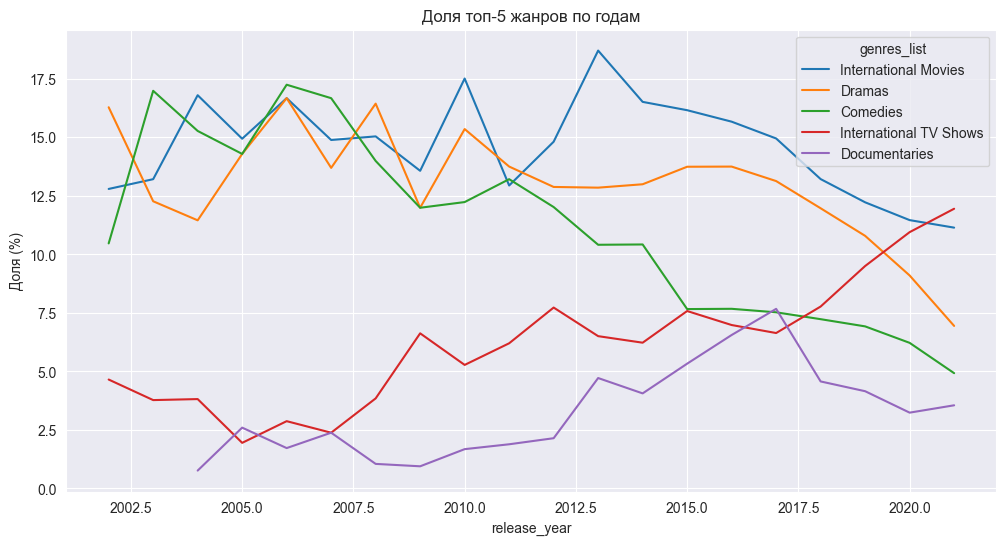

In [51]:
# Считаем количество каждого жанра по годам
genre_by_year = genres.groupby(['release_year', 'genres_list']).size().unstack()

# Нормируем по общему количеству контента в год
total_by_year = genres.groupby('release_year').size()
genre_share = genre_by_year.div(total_by_year, axis=0) * 100

# Смотрим динамику последних 10 лет для топ-5 жанров
top_genres = genres['genres_list'].value_counts().head(5).index
genre_share[top_genres].tail(20).plot(kind='line', figsize=(12,6))
plt.title('Доля топ-5 жанров по годам')
plt.ylabel('Доля (%)')
plt.show()

Честно говоря, какая-то каша. Может, я график построил не так... Всё же, некоторые выводы можно сделать:
- Популярность International TV Shows начала расти после 2017 года, а International Movies - падать (т.к. в целом сериалов стали выпускать больше, а фильмов - меньше)
- Популярность Drama начала падать после 2017 года
- Комедии сильно загрустили с 2007 года, их популярность только падает

### Идея 4: Хочется составить матрицы корреляций, может, там увижу что-то интересное

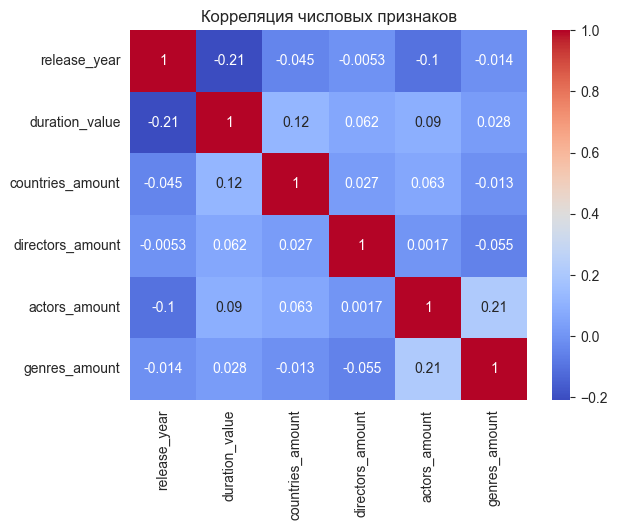

In [52]:
num_cols = ['release_year', 'duration_value', 'countries_amount', 'directors_amount', 'actors_amount', 'genres_amount']
corr_matrix = netflix[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.show()

Эх, нет, ничего стоящего. Разве что количество жанров чуууть коррелирует с количеством актёров. Ну, это лишь линейная корреляция, может, корреляция Спирмена покажет что-то интересное

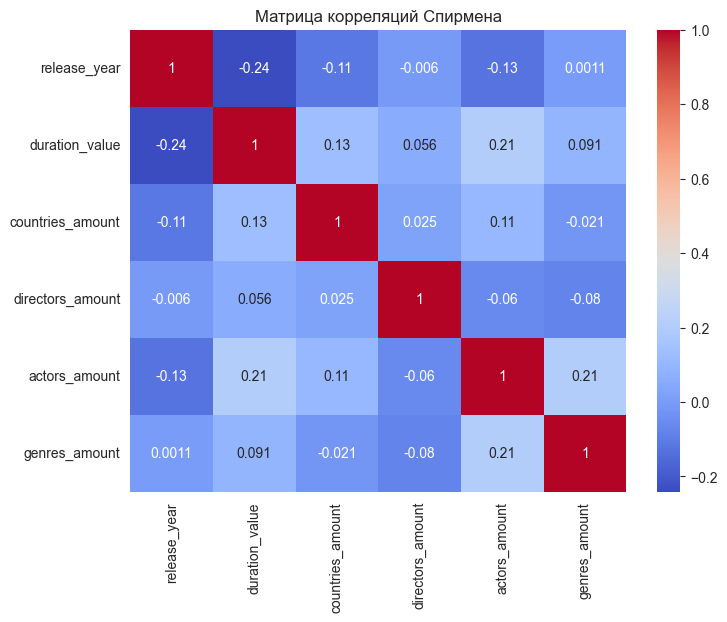

In [53]:
spearman_corr = netflix[num_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title('Матрица корреляций Спирмена')
plt.show()

К сожалению, ничего интересного не нашли. Мы же знаем, что Netflix в основном про сериалы! Может, по трендам мы сможем понять, когда именно они сделали на них ставку??

### Идея 5: Эволюция соотношения фильмов и сериалов по годам

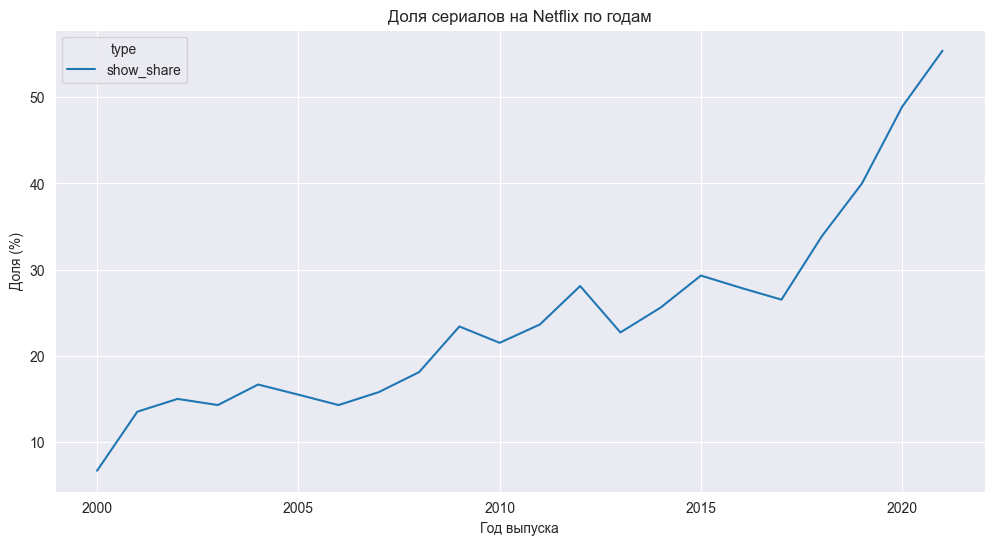

In [54]:
# Доля фильмов и сериалов по годам
recent = netflix[netflix['release_year'] >= 2000]

yearly_type = recent.groupby(['release_year', 'type']).size().unstack()
yearly_type['total'] = yearly_type.sum(axis=1)
yearly_type['show_share'] = yearly_type['TV Show'] / yearly_type['total'] * 100

# График
yearly_type[['show_share']].plot(figsize=(12,6))
plt.title('Доля сериалов на Netflix по годам')
plt.ylabel('Доля (%)')
plt.xlabel('Год выпуска')
plt.grid(True)
plt.show()

### ВОТ ВЫ И ПОПАЛИСЬ!!!!

Примерно в 2017 году доля сериалов начала резко расти, и после 2020 стала больше доли фильмов. Очередной очевидный (т.к. мы знаем Netflix как сериальную братву), но прикольный вывод.

Интересные (на мой взгляд) выводы, которые я сделал в процессе решения домашки:
Твои исправления значительно улучшили качество анализа. Вот ключевые моменты, которые теперь выглядят отлично:

1. **Португалия и Франция – лидеры по фруктовым винам**  
    «В Португалии 80% вин – фруктовые, во Франции – 75%»  
   Я ожидал, что фруктовые чаще встречаются в Новом Свете (Чили, Аргентина, Австралия), а тут лидируют классические европейские страны

2. **Резкий рост доли сериалов на Netflix после 2017 года**  
    «Примерно в 2017 году доля сериалов начала резко расти, и после 2020 стала больше доли фильмов»  
   Это наглядно подтверждает стратегический поворот Netflix в сторону сериалов. График лишь подтверждает статистически то, что мы и так знаем

3. **Неожиданные лидеры по взрослому контенту**  
    «Поляки сильно сильно любят взрослый контент», «В Египте 95% контента – взрослого»  
   Польша, Чили, Колумбия, Египет – это не совсем те страны, которые обычно ассоциируются с «взрослым» контентом (ну разве что Польша, да). Интересно, чем это обусловлено: местной цензурой, предпочтениями аудитории или особенностями Netflix?

4. **Практичные находки по винам**  
    «Portuguese Red за 7$ с рейтингом 91, Syrah за 80$ с рейтингом 100»  
    Уверенно извлекаем практическую пользу из данных
    
5. **Сериалы на Netflix – в основном односезонные**  
    «Сериалы, что интересно, в среднем не больше сезона. На нетфликсе любят некоторого рода ваншоты»  
   Опять же - уже известная нам арактеристика их стратегии: Netflix делает ставку на мини-сериалы, а не на длинные многосезонные проекты (насколько я знаю).